# Run inference for Qwen3TTS

This notebook demonstrates how to:
1. Initialize the Qwen3TTS model with dummy weights
2. Run inference with random embeddings to verify the model works


In [1]:
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
os.environ["VLLM_DISABLE_REQUEST_ID_RANDOMIZATION"] = "1"
#os.environ["VLLM_DISABLE_PAD_FOR_CUDAGRAPH"] = "1"


In [2]:
import torch
from pathlib import Path
from vllm import SamplingParams
from vllm.engine.arg_utils import AsyncEngineArgs
from vllm.v1.engine.async_llm import AsyncLLM

/home/vklimkov/miniconda3/envs/vllm/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/vklimkov/miniconda3/envs/vllm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load vLLM engine with dummy model
import json

type_str = "bfloat16"
torch_type = getattr(torch, type_str)

max_len = 256
config_path = Path("dummy_qwen3_tts_model")
engine_args = AsyncEngineArgs(
    model=str(config_path.absolute()),
    dtype=type_str,
    max_model_len=max_len,
    max_num_batched_tokens=max_len,
    gpu_memory_utilization=0.6,
    skip_tokenizer_init=True,
    enable_prefix_caching=False,
    trust_remote_code=True,
    #enforce_eager=True,
    #compilation_config={"cudagraph_mode": "PIECEWISE"},
    input_coalesce_timeout_ms=5,
    shm_decode=True,
    attention_backend="TRITON_ATTN",
)

print("Initializing engine...")
engine = AsyncLLM.from_engine_args(engine_args)

with open(config_path / "config.json") as f:
    _cfg = json.load(f)
sampling_params = SamplingParams(
    max_tokens=max_len,
    #temperature=_cfg.get("temperature", 0.9),
    temperature=0.9,
    top_k=_cfg.get("top_k", 50),
    top_p=_cfg.get("top_p", 1.0),
    repetition_penalty=_cfg.get("repetition_penalty", 1.0),
)

print("Engine initialized successfully")


PreTrainedConfig got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}
PreTrainedConfig got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}


Initializing engine...
INFO 04-17 12:52:02 [model.py:611] Resolved architecture: Qwen3TTSForConditionalGeneration
INFO 04-17 12:52:02 [model.py:1778] Using max model len 256


2026-04-17 12:52:02,711	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 04-17 12:52:02 [scheduler.py:241] Chunked prefill is enabled with max_num_batched_tokens=256.
INFO 04-17 12:52:02 [vllm.py:790] Asynchronous scheduling is enabled.


PreTrainedConfig got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}
PreTrainedConfig got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}
/home/vklimkov/miniconda3/envs/vllm/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


...

(EngineCore pid=3922020) INFO 04-17 12:52:12 [gpu_model_runner.py:4808] Starting to load model /home/vklimkov/workspace/vllm/vllm/dummy_qwen3_tts_model...
(EngineCore pid=3922020) INFO 04-17 12:52:12 [cuda.py:274] Using AttentionBackendEnum.TRITON_ATTN backend.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.77it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.77it/s]
(EngineCore pid=3922020) 


(EngineCore pid=3922020) INFO 04-17 12:52:13 [default_loader.py:384] Loading weights took 0.37 seconds
(EngineCore pid=3922020) INFO 04-17 12:52:13 [gpu_model_runner.py:4893] Model loading took 3.63 GiB memory and 0.489619 seconds
(EngineCore pid=3922020) INFO 04-17 12:52:14 [backends.py:1051] Using cache directory: /home/vklimkov/.cache/vllm/torch_compile_cache/0bedbdc306/rank_0_0/code_predictor for vLLM's torch.compile
(EngineCore pid=3922020) INFO 04-17 12:52:14 [backends.py:1111] Dynamo bytecode transform time: 0.56 s
(EngineCore pid=3922020) INFO 04-17 12:52:14 [backends.py:372] Cache the graph of compile range (1, 256) for later use
(EngineCore pid=3922020) INFO 04-17 12:52:14 [backends.py:390] Compiling a graph for compile range (1, 256) takes 0.24 s
(EngineCore pid=3922020) INFO 04-17 12:52:14 [decorators.py:640] saved AOT compiled function to /home/vklimkov/.cache/vllm/torch_compile_cache/torch_aot_compile/01a78df385c202a2e7c3a4e14c93da3c95bfb0ebf4369438909c2fef0c0e6b92/rank_0

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 35/35 [00:06<00:00,  5.80it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 19/19 [00:01<00:00, 14.38it/s]


(EngineCore pid=3922020) INFO 04-17 12:52:28 [gpu_model_runner.py:6119] Graph capturing finished in 8 secs, took 0.60 GiB
(EngineCore pid=3922020) INFO 04-17 12:52:28 [gpu_worker.py:597] CUDA graph pool memory: 0.6 GiB (actual), 0.44 GiB (estimated), difference: 0.16 GiB (26.4%).
(EngineCore pid=3922020) INFO 04-17 12:52:28 [core.py:294] init engine (profile, create kv cache, warmup model) took 15.36 seconds
(EngineCore pid=3922020) INFO 04-17 12:52:29 [vllm.py:790] Asynchronous scheduling is enabled.
Engine initialized successfully


In [4]:
# prepare prefill tokens
from transformers import AutoTokenizer
from vllm.model_executor.models.qwen3_tts import Qwen3TTSTalkerForConditionalGeneration


with open(config_path / "config.json") as f:
  config = json.load(f)
tokenizer = AutoTokenizer.from_pretrained(str(config_path.absolute()))
text_ids, group0_ids = Qwen3TTSTalkerForConditionalGeneration.build_prefill_tokens(
  tokenizer=tokenizer,
  text="Another example, to see that everything is actually fine before moving this to the server as well.",
  speaker="aiden",
  language="english",
  config=config,
)
print(f"Prefill text_ids {text_ids.shape}, group0_ids {group0_ids.shape}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.
PreTrainedConfig got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}
PreTrainedConfig got `key=rope_scaling` in kwargs but hasn't set it as attribute. For RoPE standardization you need to set `self.rope_parameters` in model's config. 
Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'interleaved', 'mrope_interleaved'}
The tokenizer you are loading from '/home/vklimkov/workspace/vl

Prefill text_ids torch.Size([30]), group0_ids torch.Size([30])


In [5]:
request_id = "test_request_1"

tc = config["talker_config"]
codec_eos_token_id = tc["codec_eos_token_id"]
tts_pad_token_id = config["tts_pad_token_id"]
hidden_size = tc["hidden_size"]

prompt_len = text_ids.shape[0]

inputs = {
    "prompt_token_ids": group0_ids.tolist(),
    "custom_inputs": {
        "text_ids": text_ids,
        "prev_hidden": torch.zeros(prompt_len, hidden_size, dtype=torch.bfloat16),
    },
}

print(f"Starting generation with request_id: {request_id}")
print(f"Prompt length: {prompt_len}")

queue = await engine.add_request(request_id, inputs, sampling_params)
prefill_output = await queue.get()
custom_out = prefill_output.outputs[0].custom_outputs

prev_hidden = custom_out["hidden"][-1:].clone()  # [1, hidden_size]
prev_group0 = prefill_output.outputs[0].token_ids[-1]


generated_codecs = []

decode_text_id = torch.tensor([tts_pad_token_id], dtype=torch.long)

for step in range(max_len - 1):
    outputs = engine.decode_step_shm(
        request_id,
        custom_inputs={
            "text_ids": decode_text_id,
            "prev_hidden": prev_hidden,
        },
    )

    codes_1_15 = outputs["codes"][-1:].clone()  # [1, 15]
    prev_hidden = outputs["hidden"][-1:].clone()  # [1, hidden_size]

    # Assemble complete codec frame: [group0, codes_1_15]
    frame = torch.cat([
        torch.tensor([[prev_group0]], dtype=torch.long),
        codes_1_15,
    ], dim=-1)  # [1, 16]
    generated_codecs.append(frame)

    sampled_token = outputs.get("sampled_token_ids")
    #g0_tok = int(sampled_token[-1]) if sampled_token is not None else prev_group0
    g0_tok = int(sampled_token[-1])

    if g0_tok == codec_eos_token_id:
        print(f"EOS token detected at step {step + 1}, stopping generation.")
        await engine.abort(request_id)
        break

    prev_group0 = g0_tok

Starting generation with request_id: test_request_1
Prompt length: 30
WARNING 04-17 12:52:29 [input_processor.py:239] Passing raw prompts to InputProcessor is deprecated and will be removed in v0.18. You should instead pass the outputs of Renderer.render_cmpl() or Renderer.render_chat().
WARNING 04-17 12:52:29 [base.py:266] Using None for EOS token id because tokenizer is not initialized
WARNING 04-17 12:52:29 [input_processor.py:187] VLLM_DISABLE_REQUEST_ID_RANDOMIZATION is set and will be removed in a future release. Duplicate externally-provided request IDs may cause failures and/or subtle correctness errors.
EOS token detected at step 67, stopping generation.


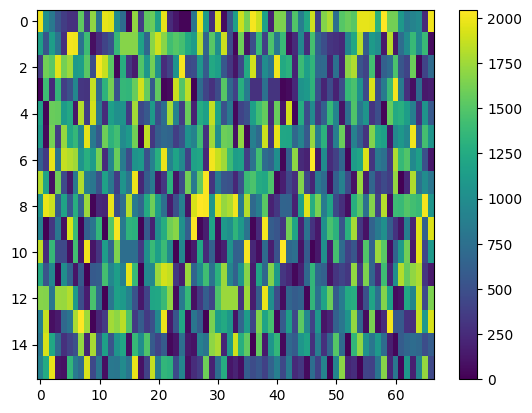

In [6]:
if generated_codecs:
    arr = torch.cat(generated_codecs, dim=0)[:100]

    import matplotlib.pyplot as plt
    plt.imshow(arr.cpu().numpy().T, aspect='auto')
    plt.colorbar()
    plt.show()
else:
    print("No codec frames generated.")

In [7]:
print(arr.shape)
print(torch.min(arr), torch.max(arr))
torch.save(arr, "/home/vklimkov/workspace/qwen3_tts/Qwen3-TTS/vllm_pred_tokens.pt")

torch.Size([67, 16])
tensor(0) tensor(2046)


## Streaming TTS (incremental text conditioning)

This section mirrors HuggingFace `non_streaming_mode=False`: a short **prefill** (`build_streaming_prefill_tokens` — first synthesis token fused with `codec_bos`), then each **decode** step passes the next entry from `build_streaming_decode_text_ids` (remaining characters + `tts_eos`, then `tts_pad`), while group-0 tokens are sampled as usual.

Use a fresh `request_id` so it does not collide with the batch demo above.

In [8]:
# Streaming-style prefill + per-decode-step text_ids schedule
# (Uses config / tokenizer from above; does not require running the batch decode cell.)
tc = config["talker_config"]
hidden_size = tc["hidden_size"]
tts_pad_token_id = config["tts_pad_token_id"]
codec_eos_token_id = tc["codec_eos_token_id"]

stream_text = (
    "Short streaming demo phrase, aligned with HF trailing_text_hidden scheduling."
)
text_ids_s, group0_ids_s = (
    Qwen3TTSTalkerForConditionalGeneration.build_streaming_prefill_tokens(
        tokenizer=tokenizer,
        text=stream_text,
        speaker="aiden",
        language="english",
        config=config,
    )
)
decode_text_schedule = (
    Qwen3TTSTalkerForConditionalGeneration.build_streaming_decode_text_ids(
        tokenizer=tokenizer,
        text=stream_text,
        config=config,
    )
)
print(f"Streaming prefill: text_ids {text_ids_s.shape}, group0_ids {group0_ids_s.shape}")
print(f"Decode text schedule length: {decode_text_schedule.numel()} (tail + tts_eos)")

Streaming prefill: text_ids torch.Size([10]), group0_ids torch.Size([10])
Decode text schedule length: 13 (tail + tts_eos)


In [9]:
request_id_stream = "test_request_streaming"

prompt_len_s = text_ids_s.shape[0]
inputs_stream = {
    "prompt_token_ids": group0_ids_s.tolist(),
    "custom_inputs": {
        "text_ids": text_ids_s,
        "prev_hidden": torch.zeros(prompt_len_s, hidden_size, dtype=torch.bfloat16),
    },
}

queue_s = await engine.add_request(request_id_stream, inputs_stream, sampling_params)
prefill_output_s = await queue_s.get()
custom_out_s = prefill_output_s.outputs[0].custom_outputs

prev_hidden_s = custom_out_s["hidden"][-1:].clone()
prev_group0_s = int(prefill_output_s.outputs[0].token_ids[-1])

generated_codecs_stream = []
for step in range(max_len - 1):
    decode_text_id = (
        Qwen3TTSTalkerForConditionalGeneration.streaming_decode_text_id_at_step(
            decode_text_schedule,
            step,
            tts_pad_token_id,
        )
    )
    outputs = engine.decode_step_shm(
        request_id_stream,
        custom_inputs={
            "text_ids": decode_text_id,
            "prev_hidden": prev_hidden_s,
        },
    )

    codes_1_15 = outputs["codes"][-1:].clone()
    prev_hidden_s = outputs["hidden"][-1:].clone()

    frame = torch.cat(
        [
            torch.tensor([[prev_group0_s]], dtype=torch.long),
            codes_1_15,
        ],
        dim=-1,
    )
    generated_codecs_stream.append(frame)

    sampled_token = outputs.get("sampled_token_ids")
    g0_tok = int(sampled_token[-1])
    if g0_tok == codec_eos_token_id:
        print(f"[streaming] EOS at decode step {step + 1}")
        await engine.abort(request_id_stream)
        break

    prev_group0_s = g0_tok

print(f"[streaming] collected {len(generated_codecs_stream)} frames")

(EngineCore pid=3922020) INFO 04-17 12:52:31 [gpu_model_runner.py:6614] Zeroed 0 tensors across 7 blocks
[streaming] EOS at decode step 65
[streaming] collected 65 frames


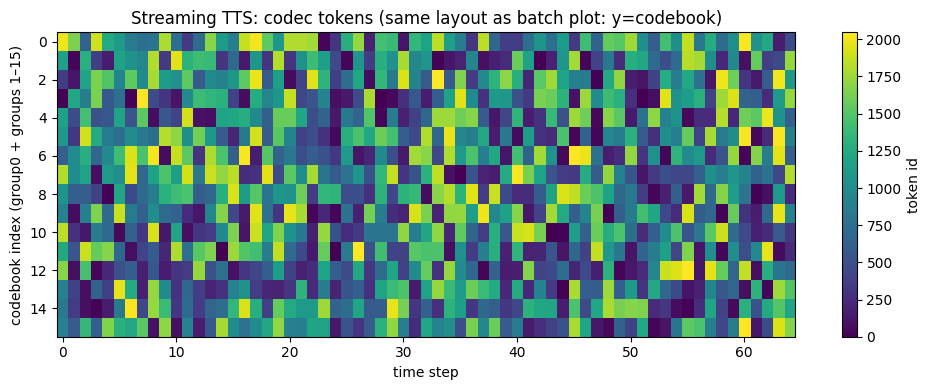

arr_streaming shape [time, 16]: (65, 16)


In [10]:
if generated_codecs_stream:
    arr_streaming = torch.cat(generated_codecs_stream, dim=0)[:200]
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))
    plt.title("Streaming TTS: codec tokens (same layout as batch plot: y=codebook)")
    # [T, 16] -> transpose so rows = codebook index, cols = time (matches cell above)
    plt.imshow(arr_streaming.cpu().numpy().T, aspect="auto", interpolation="nearest")
    plt.xlabel("time step")
    plt.ylabel("codebook index (group0 + groups 1–15)")
    plt.colorbar(label="token id")
    plt.tight_layout()
    plt.show()
    print("arr_streaming shape [time, 16]:", tuple(arr_streaming.shape))
else:
    print("No streaming codec frames generated.")